In [3]:
import pandas as pd
import numpy  as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

import plotly.express as px


In [4]:
 #1. Get the folder where your current notebook is saved
notebook_dir = Path.cwd()

# 2. Go up the folder tree to a shared folder (e.g., up 1 level)
# Use .parent to go up one level, or .parent.parent to go up two levels
root_dir = notebook_dir.parent.parent

# 3. Build the path to the target folder and file
file_path_lucidworks = root_dir / "data" / "raw" / "extract_fusion_logs_april_2026.csv"
print(file_path_lucidworks)

/Users/johnmarsden/Documents/DS_Projects/ds_project/data/raw/extract_fusion_logs_april_2026.csv


In [35]:
df = pd.read_csv(file_path_lucidworks)
print(df.columns.tolist())

['Date', 'Host', 'Service', 'Content']


In [36]:
# 1. Convert Date column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='ISO8601')

# 2. Extract the specific columns
df['year']  = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day']   = df['Date'].dt.day
df['time']  = df['Date'].dt.strftime('%H:%M:%S')
df['Day of Week'] = df['Date'].apply(lambda time: time.dayofweek)
dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
df['Day of Week'] = df['Day of Week'].map(dmap)
df

,Date,Host,Service,Content,year,month,day,time,Day of Week
0,2026-04-22 13:07:24.606000+00:00,ip-10-236-36-220,wesco-sapi-lucidworks-dr,"queryParams to partSearch: { ""start"": ""0"", ""ro...",2026,4,22,13:07:24,Wed
1,2026-04-22 12:54:49.495000+00:00,ip-10-236-38-105,wesco-sapi-lucidworks-dr,"queryParams to partSearch: { ""start"": ""0"", ""ro...",2026,4,22,12:54:49,Wed
2,2026-04-22 12:49:23.758000+00:00,ip-10-236-36-220,wesco-sapi-lucidworks-dr,"queryParams to partSearch: { ""start"": ""0"", ""ro...",2026,4,22,12:49:23,Wed
3,2026-04-22 12:45:39.310000+00:00,ip-10-236-38-105,wesco-sapi-lucidworks-dr,"queryParams to partSearch: { ""start"": ""0"", ""ro...",2026,4,22,12:45:39,Wed
4,2026-04-22 12:37:32.168000+00:00,ip-10-236-38-105,wesco-sapi-lucidworks-dr,"queryParams to partSearch: { ""start"": ""0"", ""ro...",2026,4,22,12:37:32,Wed
...,...,...,...,...,...,...,...,...,...
884,2026-04-07 14:47:06.989000+00:00,ip-10-236-36-220,wesco-sapi-lucidworks-dr,"queryParams to partSearch: { ""start"": ""0"", ""ro...",2026,4,7,14:47:06,Tue
885,2026-04-07 14:40:18.503000+00:00,ip-10-236-36-220,wesco-sapi-lucidworks-dr,"queryParams to partSearch: { ""start"": ""0"", ""ro...",2026,4,7,14:40:18,Tue
886,2026-04-07 14:17:05.075000+00:00,ip-10-236-36-220,wesco-sapi-lucidworks-dr,"queryParams to partSearch: { ""start"": ""0"", ""ro...",2026,4,7,14:17:05,Tue
887,2026-04-07 14:15:01.889000+00:00,ip-10-236-36-220,wesco-sapi-lucidworks-dr,"queryParams to partSearch: { ""start"": ""0"", ""ro...",2026,4,7,14:15:01,Tue


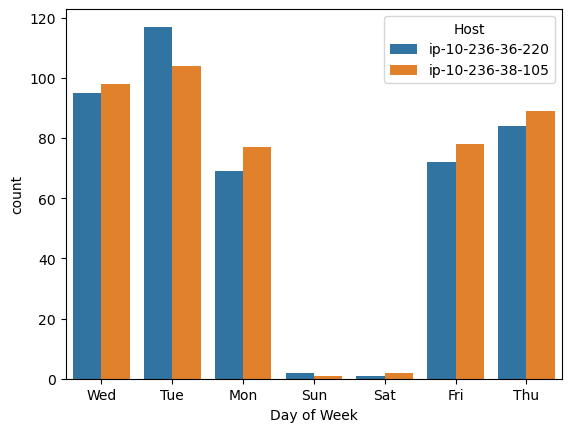

In [37]:
sns.countplot(df, x='Day of Week', hue='Host')
plt.show()

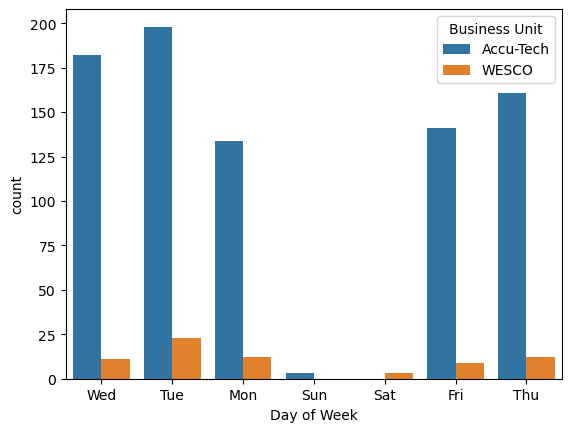

In [44]:
# 1. Extract the string after 'businessUnit_s:' 
# This regex looks for businessUnit_s: and captures everything until the next " or boundary
df['Business Unit'] = df['Content'].str.extract(r'businessUnit_s:([^"& ]+)')

sns.countplot(df, x='Day of Week', hue='Business Unit')
plt.show()